In [75]:
import pandas as pd
import sqlalchemy as sa

In [76]:
engine = sa.create_engine(
    "mssql+pyodbc:///?odbc_connect="
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=RailwayDB;"
    "Trusted_Connection=yes;"
)

In [77]:
trips = pd.read_sql("SELECT * FROM Trip", engine)
trips

,Id,TrainId,RouteId,DepartureTime,ArrivalTime,ActualArrivalTime
0,1,1,1,2026-05-02 08:00:00,2026-05-02 10:00:00,2026-05-02 10:00:00
1,2,1,1,2026-05-03 08:00:00,2026-05-03 10:00:00,2026-05-03 10:20:00
2,3,1,1,2026-05-04 08:00:00,2026-05-04 10:00:00,2026-05-04 10:35:00
3,4,2,1,2026-05-02 12:00:00,2026-05-02 14:00:00,2026-05-02 14:10:00
4,5,2,1,2026-05-03 12:00:00,2026-05-03 14:00:00,2026-05-03 14:00:00
5,6,2,1,2026-05-04 12:00:00,2026-05-04 14:00:00,2026-05-04 14:45:00
6,7,3,2,2026-05-02 09:00:00,2026-05-02 12:00:00,2026-05-02 12:30:00
7,8,3,2,2026-05-03 09:00:00,2026-05-03 12:00:00,2026-05-03 12:55:00
8,9,3,2,2026-05-04 09:00:00,2026-05-04 12:00:00,2026-05-04 12:20:00
9,10,5,3,2026-05-02 07:00:00,2026-05-02 08:00:00,2026-05-02 08:00:00


In [78]:
shape = trips.shape
shape

(17, 6)

In [79]:
trips.dtypes

Id                            int64
TrainId                       int64
RouteId                       int64
DepartureTime        datetime64[us]
ArrivalTime          datetime64[us]
ActualArrivalTime    datetime64[us]
dtype: object

In [80]:
delays = pd.read_sql("SELECT * FROM Delays", engine)
routes = pd.read_sql("SELECT * FROM Routes", engine)
routeStations = pd.read_sql("SELECT * FROM RouteStations", engine)
stations = pd.read_sql("SELECT * FROM Stations", engine)
trains = pd.read_sql("SELECT * FROM Trains", engine)
trainTypes = pd.read_sql("SELECT * FROM TrainTypes", engine)
users = pd.read_sql("SELECT * FROM Users", engine)

In [81]:
print("Delays:", delays.shape)
print("Routes:", routes.shape)
print("RouteStations:", routeStations.shape)
print("Stations:", stations.shape)
print("Trains:", trains.shape)
print("TrainTypes:", trainTypes.shape)
print("Users:", users.shape)

Delays: (10, 7)
Routes: (3, 2)
RouteStations: (8, 6)
Stations: (5, 7)
Trains: (5, 3)
TrainTypes: (4, 6)
Users: (0, 6)


In [82]:
trips_with_routes = trips.merge(routes, left_on="RouteId", right_on="Id", suffixes=("_trip", "_route"))
trips_with_routes.head()

,Id_trip,TrainId,RouteId,DepartureTime,ArrivalTime,ActualArrivalTime,Id_route,Name
0,1,1,1,2026-05-02 08:00:00,2026-05-02 10:00:00,2026-05-02 10:00:00,1,Belgrade - Subotica
1,2,1,1,2026-05-03 08:00:00,2026-05-03 10:00:00,2026-05-03 10:20:00,1,Belgrade - Subotica
2,3,1,1,2026-05-04 08:00:00,2026-05-04 10:00:00,2026-05-04 10:35:00,1,Belgrade - Subotica
3,4,2,1,2026-05-02 12:00:00,2026-05-02 14:00:00,2026-05-02 14:10:00,1,Belgrade - Subotica
4,5,2,1,2026-05-03 12:00:00,2026-05-03 14:00:00,2026-05-03 14:00:00,1,Belgrade - Subotica


In [83]:
trips_with_routes = trips_with_routes[["Id_trip", "TrainId", "RouteId", "Name", "DepartureTime", "ArrivalTime", "ActualArrivalTime"]]
trips_with_routes = trips_with_routes.rename(columns={"Id_trip": "TripId", "Name": "RouteName"})
trips_with_routes.head()

,TripId,TrainId,RouteId,RouteName,DepartureTime,ArrivalTime,ActualArrivalTime
0,1,1,1,Belgrade - Subotica,2026-05-02 08:00:00,2026-05-02 10:00:00,2026-05-02 10:00:00
1,2,1,1,Belgrade - Subotica,2026-05-03 08:00:00,2026-05-03 10:00:00,2026-05-03 10:20:00
2,3,1,1,Belgrade - Subotica,2026-05-04 08:00:00,2026-05-04 10:00:00,2026-05-04 10:35:00
3,4,2,1,Belgrade - Subotica,2026-05-02 12:00:00,2026-05-02 14:00:00,2026-05-02 14:10:00
4,5,2,1,Belgrade - Subotica,2026-05-03 12:00:00,2026-05-03 14:00:00,2026-05-03 14:00:00


In [84]:
trips_with_routes_trains = trips_with_routes.merge(trains, left_on="TrainId", right_on="Id", suffixes=("_trip", "_train"))
trips_with_routes_trains.head()

,TripId,TrainId,RouteId,RouteName,DepartureTime,ArrivalTime,ActualArrivalTime,Id,TrainTypeId,SerialNumber
0,1,1,1,Belgrade - Subotica,2026-05-02 08:00:00,2026-05-02 10:00:00,2026-05-02 10:00:00,1,1,SRB-HS-001
1,2,1,1,Belgrade - Subotica,2026-05-03 08:00:00,2026-05-03 10:00:00,2026-05-03 10:20:00,1,1,SRB-HS-001
2,3,1,1,Belgrade - Subotica,2026-05-04 08:00:00,2026-05-04 10:00:00,2026-05-04 10:35:00,1,1,SRB-HS-001
3,4,2,1,Belgrade - Subotica,2026-05-02 12:00:00,2026-05-02 14:00:00,2026-05-02 14:10:00,2,1,SRB-HS-002
4,5,2,1,Belgrade - Subotica,2026-05-03 12:00:00,2026-05-03 14:00:00,2026-05-03 14:00:00,2,1,SRB-HS-002


In [85]:
trips_with_routes_trains = trips_with_routes_trains[["TripId", "TrainId", "TrainTypeId", "SerialNumber", "RouteId", "RouteName", "DepartureTime"
                                                     , "ArrivalTime", "ActualArrivalTime"]]
trips_with_routes_trains = trips_with_routes_trains.rename(columns={"SerialNumber": "Train"})
trips_with_routes_trains.head()

,TripId,TrainId,TrainTypeId,Train,RouteId,RouteName,DepartureTime,ArrivalTime,ActualArrivalTime
0,1,1,1,SRB-HS-001,1,Belgrade - Subotica,2026-05-02 08:00:00,2026-05-02 10:00:00,2026-05-02 10:00:00
1,2,1,1,SRB-HS-001,1,Belgrade - Subotica,2026-05-03 08:00:00,2026-05-03 10:00:00,2026-05-03 10:20:00
2,3,1,1,SRB-HS-001,1,Belgrade - Subotica,2026-05-04 08:00:00,2026-05-04 10:00:00,2026-05-04 10:35:00
3,4,2,1,SRB-HS-002,1,Belgrade - Subotica,2026-05-02 12:00:00,2026-05-02 14:00:00,2026-05-02 14:10:00
4,5,2,1,SRB-HS-002,1,Belgrade - Subotica,2026-05-03 12:00:00,2026-05-03 14:00:00,2026-05-03 14:00:00


In [86]:
print("Total trips:", len(trips_with_routes_trains))
print("Completed trips:", trips_with_routes_trains["ActualArrivalTime"].notna().sum())
print("Future/incomplete trips:", trips_with_routes_trains["ActualArrivalTime"].isna().sum())

Total trips: 17
Completed trips: 14
Future/incomplete trips: 3


In [87]:
completed_trips = trips_with_routes_trains[trips_with_routes_trains["ActualArrivalTime"].notna()].copy()

completed_trips["DelayMinutes"] = (
    completed_trips["ActualArrivalTime"] - completed_trips["ArrivalTime"]
).dt.total_seconds() / 60

completed_trips[["TripId", "Train", "RouteName", "ArrivalTime", "ActualArrivalTime", "DelayMinutes"]]

,TripId,Train,RouteName,ArrivalTime,ActualArrivalTime,DelayMinutes
0,1,SRB-HS-001,Belgrade - Subotica,2026-05-02 10:00:00,2026-05-02 10:00:00,0.0
1,2,SRB-HS-001,Belgrade - Subotica,2026-05-03 10:00:00,2026-05-03 10:20:00,20.0
2,3,SRB-HS-001,Belgrade - Subotica,2026-05-04 10:00:00,2026-05-04 10:35:00,35.0
3,4,SRB-HS-002,Belgrade - Subotica,2026-05-02 14:00:00,2026-05-02 14:10:00,10.0
4,5,SRB-HS-002,Belgrade - Subotica,2026-05-03 14:00:00,2026-05-03 14:00:00,0.0
5,6,SRB-HS-002,Belgrade - Subotica,2026-05-04 14:00:00,2026-05-04 14:45:00,45.0
6,7,SRB-PS-001,Belgrade - Nis,2026-05-02 12:00:00,2026-05-02 12:30:00,30.0
7,8,SRB-PS-001,Belgrade - Nis,2026-05-03 12:00:00,2026-05-03 12:55:00,55.0
8,9,SRB-PS-001,Belgrade - Nis,2026-05-04 12:00:00,2026-05-04 12:20:00,20.0
9,10,SRB-CM-001,Belgrade - Novi Sad,2026-05-02 08:00:00,2026-05-02 08:00:00,0.0


In [88]:
delay_routes = completed_trips.groupby("RouteName")["DelayMinutes"].agg(
    TotalDelayMinutes="sum",
    AverageDelayMinutes="mean",
    TripCount="count",
    LateTrips=lambda x: (x > 0).sum()
).round(2).reset_index()
delay_routes

,RouteName,TotalDelayMinutes,AverageDelayMinutes,TripCount,LateTrips
0,Belgrade - Nis,105.0,35.00,3,3
1,Belgrade - Novi Sad,20.0,4.00,5,2
2,Belgrade - Subotica,110.0,18.33,6,4


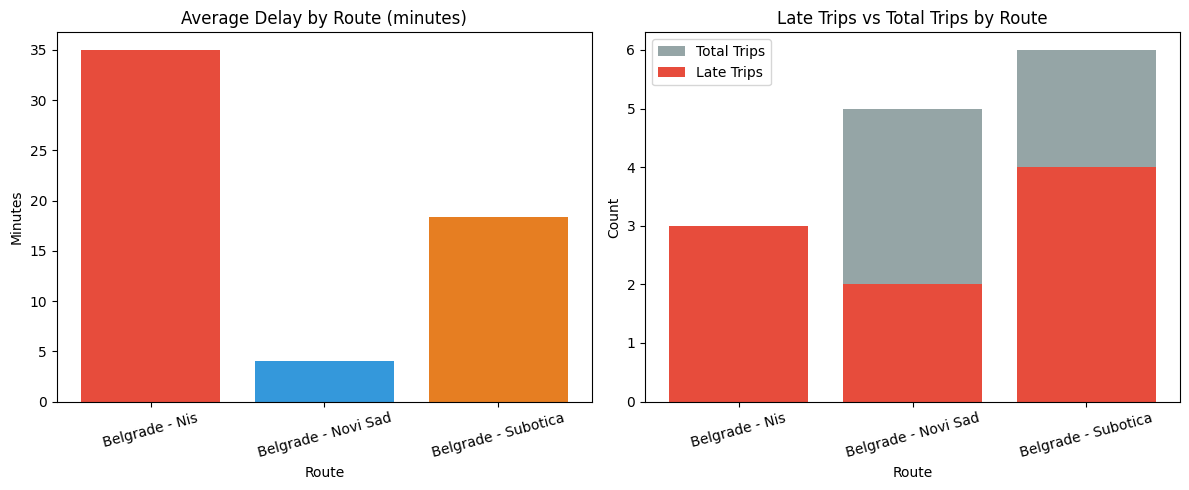

In [89]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# chart 1 — average delay per route
axes[0].bar(delay_routes["RouteName"], delay_routes["AverageDelayMinutes"], color=["#e74c3c", "#3498db", "#e67e22"])
axes[0].set_title("Average Delay by Route (minutes)")
axes[0].set_xlabel("Route")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis="x", rotation=15)

# chart 2 — late trips vs total trips
axes[1].bar(delay_routes["RouteName"], delay_routes["TripCount"], label="Total Trips", color="#95a5a6")
axes[1].bar(delay_routes["RouteName"], delay_routes["LateTrips"], label="Late Trips", color="#e74c3c")
axes[1].set_title("Late Trips vs Total Trips by Route")
axes[1].set_xlabel("Route")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

In [90]:
delays_with_stations = delays.merge(stations, left_on="StationId", right_on="Id", suffixes=("_delay","_station"))
delays_with_stations.head()

,Id_delay,TripId,StationId,DelayMinutes,TypeOfDelay,CreatedAt,Note,Id_station,Name,City,Country,NumberOfPlatforms,Latitude,Longitude
0,1,2,1,20,1,2026-05-03 08:30:00,Technical issue at Belgrade,1,Belgrade Center,Belgrade,Serbia,10,None,None
1,2,3,2,35,3,2026-05-04 08:30:00,Track maintenance on Novi Sad section,2,Novi Sad,Novi Sad,Serbia,6,None,None
2,3,4,1,10,1,2026-05-02 12:30:00,Technical issue at Belgrade,1,Belgrade Center,Belgrade,Serbia,10,None,None
3,4,6,2,45,3,2026-05-04 12:30:00,Track maintenance on Novi Sad section,2,Novi Sad,Novi Sad,Serbia,6,None,None
4,5,7,4,15,0,2026-05-02 10:00:00,Weather conditions on Nis route,4,Nis,Nis,Serbia,5,None,None


In [91]:
delays_with_stations = delays_with_stations[["Id_delay", "TripId", "StationId", "Name", "DelayMinutes", "TypeOfDelay"]]
delays_with_stations = delays_with_stations.rename(columns={"Id_delay": "DelayId", "Name": "StationName"})
delays_with_stations

,DelayId,TripId,StationId,StationName,DelayMinutes,TypeOfDelay
0,1,2,1,Belgrade Center,20,1
1,2,3,2,Novi Sad,35,3
2,3,4,1,Belgrade Center,10,1
3,4,6,2,Novi Sad,45,3
4,5,7,4,Nis,15,0
5,6,7,1,Belgrade Center,15,2
6,7,8,4,Nis,27,0
7,8,8,1,Belgrade Center,27,2
8,9,9,4,Nis,10,0
9,10,9,1,Belgrade Center,10,2


In [92]:
delay_type_map = {
    0 : "Weather", 
    1 :"Technical", 
    2 :"StationCongestion", 
    3 :"TrackMaintenance", 
    4 :"PassengerIncident", 
    5 :"ExternalFactor", 
    6 :"Other"
}

delays_with_stations["TypeOfDelay"] = delays_with_stations["TypeOfDelay"].map(delay_type_map)

delays_with_stations

,DelayId,TripId,StationId,StationName,DelayMinutes,TypeOfDelay
0,1,2,1,Belgrade Center,20,Technical
1,2,3,2,Novi Sad,35,TrackMaintenance
2,3,4,1,Belgrade Center,10,Technical
3,4,6,2,Novi Sad,45,TrackMaintenance
4,5,7,4,Nis,15,Weather
5,6,7,1,Belgrade Center,15,StationCongestion
6,7,8,4,Nis,27,Weather
7,8,8,1,Belgrade Center,27,StationCongestion
8,9,9,4,Nis,10,Weather
9,10,9,1,Belgrade Center,10,StationCongestion


In [93]:
delays_with_stations.columns

Index(['DelayId', 'TripId', 'StationId', 'StationName', 'DelayMinutes',
       'TypeOfDelay'],
      dtype='str')

In [96]:
delays_by_station = delays_with_stations.groupby("StationName")["DelayMinutes"].agg(
    TotalDelayMinutes="sum",
    AverageDelayMinutes="mean",
    DelayCount="count"
).round(2).reset_index().sort_values("TotalDelayMinutes", ascending=False)

delays_by_station

,StationName,TotalDelayMinutes,AverageDelayMinutes,DelayCount
0,Belgrade Center,82,16.40,5
2,Novi Sad,80,40.00,2
1,Nis,52,17.33,3


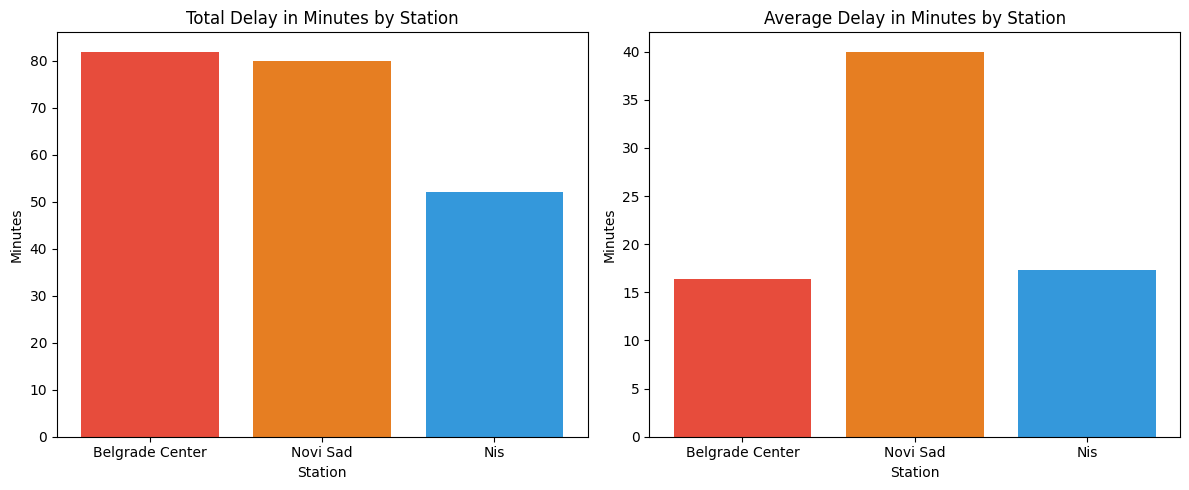

: 

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12,5))

axis[0].bar(delays_by_station["StationName"], delays_by_station["TotalDelayMinutes"], color=["#e74c3c", "#e67e22", "#3498db"])
axis[0].set_title("Total Delay in Minutes by Station")
axis[0].set_xlabel("Station")
axis[0].set_ylabel("Minutes")

axis[1].bar(delays_by_station["StationName"], delays_by_station["AverageDelayMinutes"], color=["#e74c3c", "#e67e22", "#3498db"])
axis[1].set_title("Average Delay in Minutes by Station")
axis[1].set_xlabel("Station")
axis[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()